Loaded: (9850, 10)
   Unnamed: 0                 name  height  width  left  top  right  bottom  \
0           0  vehicle_0000001.jpg    1080   1920   597    3    935     341   
1           1  vehicle_0000002.jpg    1080   1920   399  283    875     874   
2           2  vehicle_0000003.jpg    1080   1920   597   97    970     538   
3           3  vehicle_0000004.jpg    1080   1920   671    5    978     308   
4           4  vehicle_0000005.jpg    1080   1920   502  341    927     844   

  category  nVehicles  
0      SUV          1  
1      SUV          1  
2      SUV          1  
3    Sedan          1  
4    Sedan          1  
Processing images...
Feature shape: (9850, 1764)
Training SVM...

Classification Report:
              precision    recall  f1-score   support

         Bus       0.99      0.95      0.97       111
    Microbus       0.92      0.84      0.88       172
     Minivan       0.85      0.74      0.79        93
         SUV       0.95      0.91      0.93       275
  

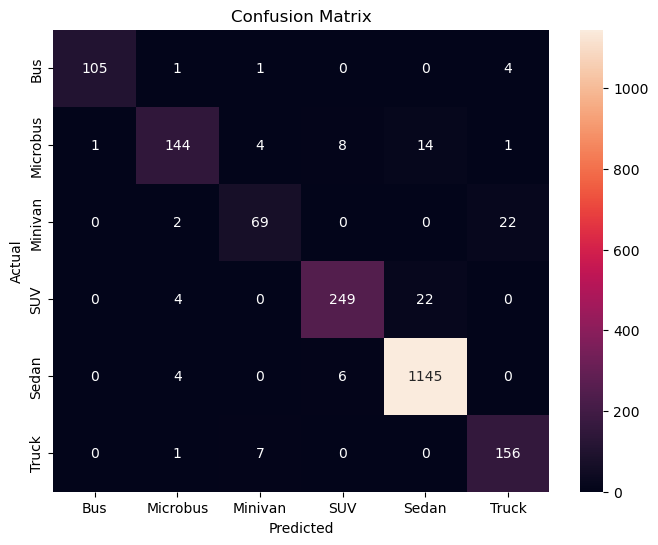

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# File paths
IMAGE_FOLDER = "C:/Users/clair/Downloads/BITVehicle"   
CSV_FILE = "C:/Users/clair/Downloads/BITVehicle/VehicleInfo.csv"
IMG_SIZE = (64, 64)
TEST_SIZE = 0.2


df = pd.read_csv(CSV_FILE)

print("Loaded:", df.shape)
print(df.head())

# Extract features
features = []
labels = []

print("Processing images...")

for _, row in df.iterrows():
    img_name = row["name"]
    label = row["category"]

    # Bounding box
    left = int(row["left"])
    top = int(row["top"])
    right = int(row["right"])
    bottom = int(row["bottom"])

    img_path = os.path.join(IMAGE_FOLDER, img_name)

    if not os.path.exists(img_path):
        print("Could not process:", img_path)
        continue

    # Load image
    img = cv2.imread(img_path)

    # Crop vehicle using bounding box
    crop = img[top:bottom, left:right]

    # Skip bad crops
    if crop.size == 0:
        continue

    # Resize
    crop = cv2.resize(crop, IMG_SIZE)

    # Convert to grayscale
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    # HOG features
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    features.append(hog_features)
    labels.append(label)

features = np.array(features)
labels = np.array(labels)

print("Feature shape:", features.shape)

# Encode lables
le = LabelEncoder()
y = le.fit_transform(labels)

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    features, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
print("Training SVM...")

svm = SVC(
    kernel='rbf',   # change to 'linear' if slow
    C=10,
    gamma='scale',
    probability= True
)

svm.fit(X_train, y_train)

# Evaluate SVM
y_pred = svm.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [2]:
# Save model
import joblib

joblib.dump(svm, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']